In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv('Cellphone.csv')

In [3]:
df.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [4]:
df.describe()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [6]:
df.isnull().sum()

Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

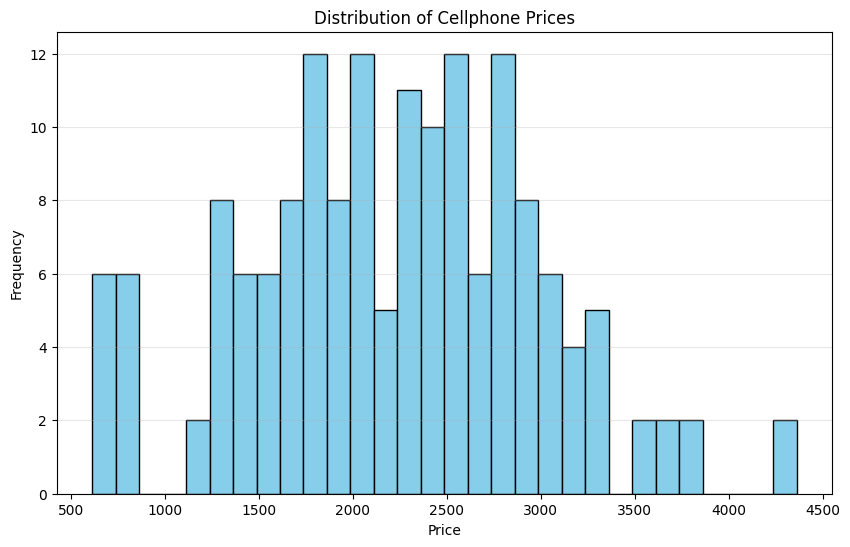

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(df['Price'], bins=30, edgecolor='black', color='skyblue')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Cellphone Prices')
plt.grid(axis='y', alpha=0.3)
plt.show()

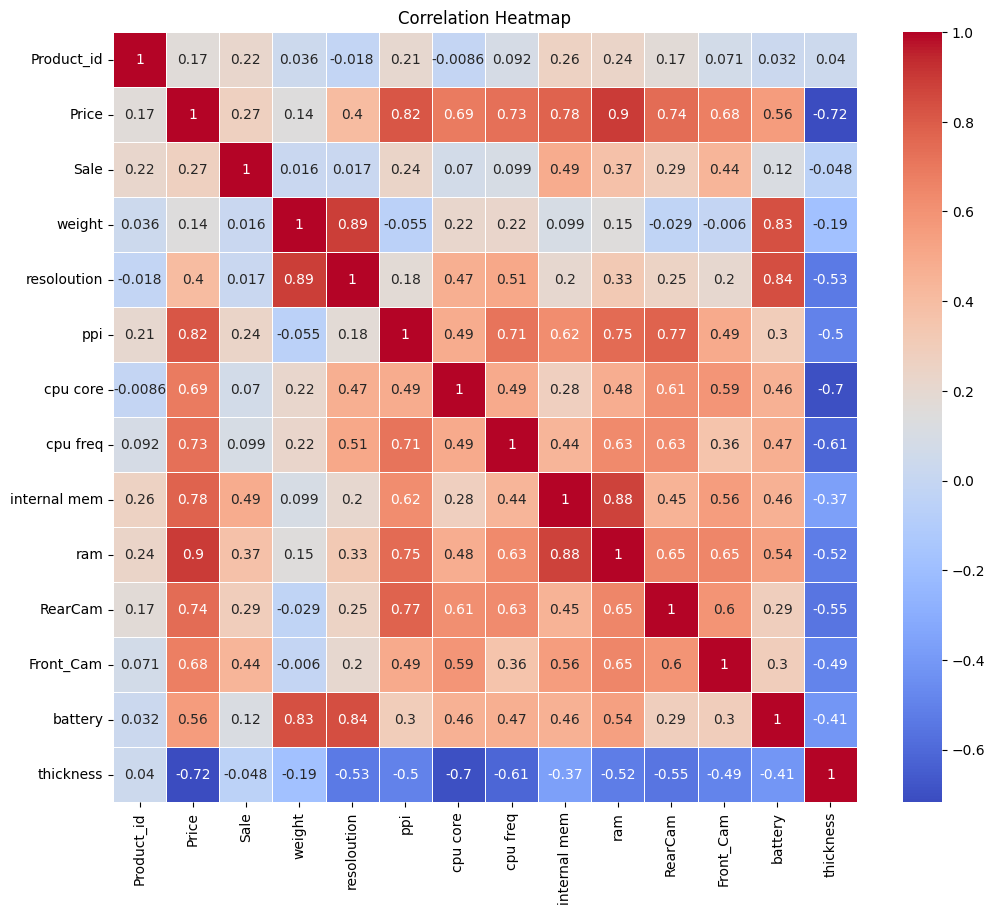

In [8]:
import seaborn as sns

plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [9]:
X = df.drop(['Price', 'Sale'], axis=1)
y = df['Price']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
X_train_scaled

array([[-0.08656055,  0.06407114,  0.35114803, ...,  0.07015893,
         0.28920963, -0.5850085 ],
       [-1.54352334, -0.68307592, -0.31920168, ...,  0.07015893,
        -0.62975187, -0.5850085 ],
       [ 1.59736629,  0.30689394,  0.35114803, ..., -0.8323881 ,
         0.44236988,  0.54494407],
       ...,
       [ 1.05070018, -0.27447987, -0.05106179, ..., -0.60675134,
        -0.01711087, -0.36770993],
       [-1.32144023, -0.16941231, -0.11809677, ...,  0.07015893,
        -0.55317175, -0.23733078],
       [-1.1945356 , -0.09936728, -0.11809677, ..., -1.05802486,
        -0.24685125,  0.80570236]], shape=(128, 12))

In [13]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

c:\Users\gargn\OneDrive\Desktop\Neha\DSML Projects\Deployment\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

         614       0.00      0.00      0.00         0
         833       0.00      0.00      0.00         2
        1238       0.00      0.00      0.00         1
        1302       0.00      0.00      0.00         0
        1347       0.00      0.00      0.00         1
        1396       0.00      0.00      0.00         0
        1511       0.00      0.00      0.00         1
        1522       0.00      0.00      0.00         1
        1612       0.00      0.00      0.00         2
        1646       1.00      1.00      1.00         1
        1676       0.00      0.00      0.00         1
        1734       0.00      0.00      0.00         0
        1777       0.00      0.00      0.00         1
        1942       0.33      1.00      0.50         1
        1950       0.00      0.00      0.00         1
        1989       0.00      0.00      0.00         0
        2001       0.00      0.00      0.00         0
        2054       0.00    

c:\Users\gargn\OneDrive\Desktop\Neha\DSML Projects\Deployment\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gargn\OneDrive\Desktop\Neha\DSML Projects\Deployment\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gargn\OneDrive\Desktop\Neha\DSML Projects\Deployment\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control

In [15]:
model={
    'Linear Regression': LinearRegression(),    
    'Lasso Regression': Lasso(alpha=0.1),
    'Ridge Regression': Ridge(alpha=0.1),
    'ElasticNet Regression': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

In [16]:
results = []
for name, model in model.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_r2=r2_score(y_train, y_train_pred)
    test_r2=r2_score(y_test, y_test_pred)   
    train_rmse=np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse=np.sqrt(mean_squared_error(y_test, y_test_pred))
    results.append([name, train_r2, test_r2, train_rmse, test_rmse])
results_df = pd.DataFrame(results, columns=['Model', 'Train R2', 'Test R2', 'Train RMSE', 'Test RMSE'])

In [17]:
results_df=pd.DataFrame(results, columns=['Model', 'Train R2', 'Test R2', 'Train RMSE', 'Test RMSE'])
print("/nModel Performance Comparison:")
print(results_df)

/nModel Performance Comparison:
                   Model  Train R2   Test R2  Train RMSE   Test RMSE
0      Linear Regression  0.951342  0.956511  169.605885  157.014892
1       Lasso Regression  0.951341  0.956478  169.607099  157.073352
2       Ridge Regression  0.951342  0.956513  169.606399  157.010884
3  ElasticNet Regression  0.950879  0.955985  170.410767  157.960277


In [18]:
# Overfitting Check
for index, row in results_df.iterrows():
    print(f"{row['Model']} - Train R2: {row['Train R2']:.3f}, Test R2: {row['Test R2']:.3f}")

Linear Regression - Train R2: 0.951, Test R2: 0.957
Lasso Regression - Train R2: 0.951, Test R2: 0.956
Ridge Regression - Train R2: 0.951, Test R2: 0.957
ElasticNet Regression - Train R2: 0.951, Test R2: 0.956


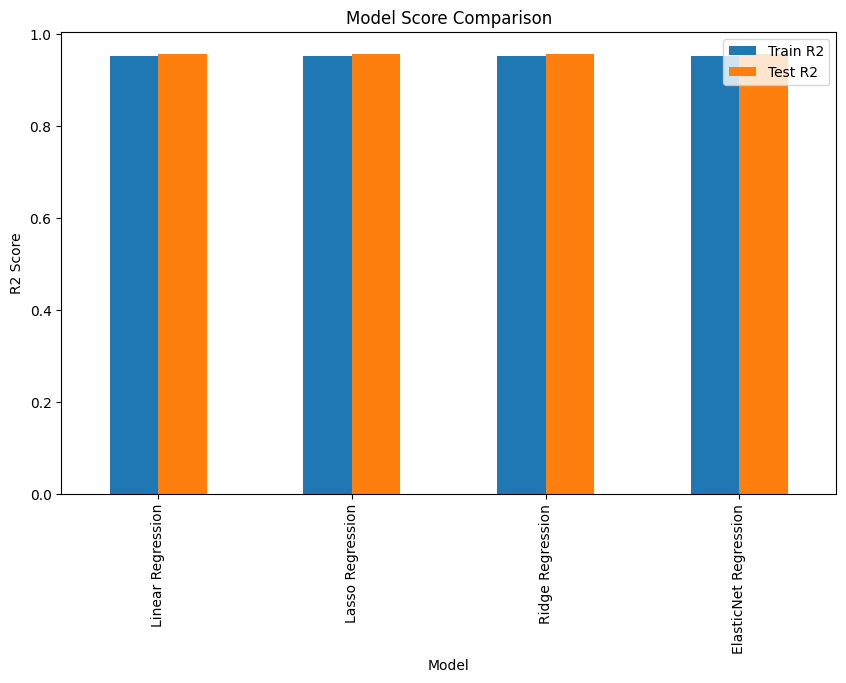

In [19]:
results_df.plot(x='Model', y=['Train R2', 'Test R2'], kind='bar', figsize=(10, 6))
plt.title('Model Score Comparison')
plt.ylabel('R2 Score')
plt.show()

In [20]:
import joblib

joblib.dump(model, "mobile_price_prediction_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Linear model and scaler saved successfully.")


Linear model and scaler saved successfully.
